## Interactive notebook to generate and pipeline

## Import dependencies

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from paidiverpy.colour_layer import ColourLayer
from paidiverpy.open_layer import OpenLayer
from paidiverpy.pipeline import Pipeline

In [3]:
from paidiverpy.config.client_params import ClientParams
from paidiverpy.config.general_config import GeneralConfig
from paidiverpy.config.open_params import ImageOpenArgsOpenCVParams
from paidiverpy.config.open_params import ImageOpenArgsRawParams
from paidiverpy.config.open_params import ImageOpenArgsRawPyParams
from paidiverpy.config.open_params import ImageOpenArgs

In [4]:
from panel.widgets import Button
from panel.widgets import FloatSlider
from panel.widgets import TextInput
from panel.widgets import JSONEditor
from importlib.resources import files
import panel as pn
pn.extension('jsoneditor', 'codeeditor', raw_css=[files("paidiverpy.static.css").joinpath("style.css").read_text()],
    raw_js=[files("paidiverpy.static.js").joinpath("script.js").read_text()])


## Creating the general part of the configuration file

In [5]:
from paidiverpy.frontend.render import *
from paidiverpy.frontend.parse import *
from paidiverpy.frontend.panel_yaml import *

ModuleNotFoundError: No module named 'paidiverpy.frontend.panel_yaml'

In [6]:
default_general_params = parse_default_params(GeneralConfig)
default_general_params

{'sample_data': {'default': None,
  'description': 'Sample data to use for testing. If provided, it will override input_path, metadata_path, and metadata_type.',
  'type': 'union',
  'field_options': {'literal': ['plankton_csv',
    'benthic_csv',
    'benthic_ifdo',
    'nef_raw',
    'benthic_raw_images'],
   'NoneType': 'NoneType'}},
 'input_path': {'type': 'str',
  'default': '',
  'description': 'Input path for image data. Can be a local path or a remote URL.'},
 'output_path': {'default': 'output',
  'description': 'Output path for results. Can be a local path or a remote URL.',
  'type': 'str'},
 'metadata_path': {'type': 'str',
  'default': '',
  'description': 'Path to metadata. Can be a local path or a remote URL.'},
 'metadata_type': {'type': 'literal',
  'default': None,
  'options': ['IFDO', 'CSV_FILE'],
  'description': "Type of metadata. Can be 'IFDO' or 'CSV_FILE'"},
 'image_open_args': {'default': '',
  'description': 'Arguments to use when opening images. It can be a 

In [8]:
pn.extension('jsoneditor', 'codeeditor', raw_css=[files("paidiverpy.static.css").joinpath("style.css").read_text()],
    raw_js=[files("paidiverpy.static.js").joinpath("script.js").read_text()])

default_general_params = parse_default_params(GeneralConfig)

# Create widgets from the general params
widget_render = WidgetRenderer()
widgets = [widget_render.create_widget(name, field) for name, field in default_general_params.items()]

# Title and submit button
title = pn.pane.HTML(
    f"<div class='ppy-pn-title-{1} ppy-pn-bold'>General Configuration Input</div>"
)
information_str = "**IMPORTANT: The fields input_path and metadata_path are required if sample_data is not provided**"
information = pn.pane.HTML(
            f"<div class='ppy-pn-title-{3} ppy-pn-bold'>{information_str}</div>"
        )
yaml_text = ""
yaml_output = pn.widgets.CodeEditor(value=yaml_text, language='yaml')
submit_button = pn.widgets.Button(name="Submit", button_type="primary")

def on_submit_general(event):
    yaml_str = extract_widget_values(inputs)
    yaml_output.value = yaml_str

submit_button.on_click(on_submit_general)

# Combine into Panel layout
inputs = pn.Column(title, information, *widgets)
form = pn.Column(
    inputs,
    pn.Row(submit_button),
    pn.pane.Markdown("### YAML Output"),
    yaml_output
)
form.servable()

Column
    [0] Column
        [0] HTML(str)
        [1] HTML(str)
        [2] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] Column
                [0] Checkbox(name='Provide sample_data?')
                [1] ParamFunction(function, _pane=TextInput, defer_load=False)
        [3] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] TextInput(name='input_path')
        [4] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] TextInput(name='output_path', value='output')
        [5] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] TextInput(name='metadata_path')
        [6] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] Select(name='metadata_type', options=['IFDO', 'CSV_FILE'], value='IFDO')
        [7] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] Column
                [0] Select(name='image_open_args t..., options=['str', 'ImageOpenArgs'], value='str')
                [1] ParamFunction(function, _pane=TextInput, defer_load=False)
        [8] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] Column
                [0] Checkbox(name='Provide append_data_to_me...)
                [1] ParamFunction(function, _pane=TextInput, defer_load=False)
        [9] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] Column
                [0] Checkbox(name='Provide metadata_conventi...)
                [1] ParamFunction(function, _pane=TextInput, defer_load=False)
        [10] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] IntInput(name='n_jobs', value=1)
        [11] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] Column
                [0] Checkbox(name='Provide client?')
                [1] ParamFunction(function, _pane=TextInput, defer_load=False)
        [12] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] Checkbox(name='track_changes', value=True)
        [13] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] Column
                [0] Checkbox(name='Provide rename?')
                [1] ParamFunction(function, _pane=TextInput, defer_load=False)
        [14] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] Column
                [0] Checkbox(name='Provide sampling?')
                [1] ParamFunction(function, _pane=TextInput, defer_load=False)
        [15] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] Column
                [0] Checkbox(name='Provide convert?')
                [1] ParamFunction(function, _pane=TextInput, defer_load=False)
    [1] Row
        [0] Button(button_type='primary', name='Submit')
    [2] Markdown(str)
    [3] CodeEditor(language='yaml')

In [45]:
result = extract_values(x)
print(result)

{'input_path': '', 'output_path': 'output', 'metadata_path': '', 'metadata_type': 'IFDO', 'image_open_args': '', 'n_jobs': 1, 'client': {'cluster_type': 'local', 'params': {'n_workers': 0}}, 'track_changes': True, 'sampling': [{'mode': 'datetime', 'params': {'raise_error': False}}], 'convert': [{'mode': 'bits', 'params': {'output_bits': 8, 'raise_error': False}}, {'mode': 'bits', 'params': {'output_bits': 8, 'raise_error': False}}]}


In [48]:
from paidiverpy.frontend.yaml_dump import extract
result = extract(inputs, return_dict=True)
print(result)


{'input_path': '', 'output_path': 'output', 'metadata_path': '', 'metadata_type': 'IFDO', 'image_open_args': '', 'n_jobs': 1, 'client': {'cluster_type': 'local', 'params': {'n_workers': 0}}, 'track_changes': True, 'sampling': [{'mode': 'datetime', 'params': {'raise_error': False}}], 'convert': [{'mode': 'bits', 'params': {'output_bits': 8, 'raise_error': False}}, {'mode': 'bits', 'params': {'output_bits': 8, 'raise_error': False}}]}


In [57]:
from paidiverpy.config.step_config import SamplingConfig
default_step_params = parse_fields_from_pydantic_model(SamplingConfig)
default_step_params

{'name': {'default': None,
  'description': 'Name of the step',
  'type': 'union',
  'field_options': {'str': 'str', 'NoneType': 'NoneType'}},
 'step_name': {'default': None,
  'description': 'Step name',
  'type': 'union',
  'field_options': {'str': 'str', 'NoneType': 'NoneType'}},
 'test': {'default': False, 'description': 'Test mode', 'type': 'bool'},
 'params': {'default': None,
  'description': 'Sampling parameters',
  'type': 'union',
  'field_options': {'SamplingDatetimeParams': 'Parameters for datetime resampling.',
   'SamplingDepthParams': 'Parameters for depth resampling.',
   'SamplingAltitudeParams': 'Parameters for altitude resampling.',
   'SamplingPitchRollParams': 'Parameters for pitch and roll resampling.',
   'SamplingOverlappingParams': 'Parameters for overlapping resampling.',
   'SamplingFixedParams': 'Parameters for fixed interval resampling.',
   'SamplingPercentParams': 'Parameters for percent-based resampling.',
   'SamplingRegionParams': 'Parameters for regio

In [17]:
default_step_params = {"steps": parse_fields_from_pydantic_model(ConfigModel)["steps"]}


In [56]:
fields = parse_fields_from_pydantic_model(GeneralConfig)
fields

{'name': {'default': 'raw',
  'description': 'Name of the first step (the step to open images)',
  'type': 'str'},
 'step_name': {'default': 'open',
  'description': 'Step name. This is a placeholder for the first step name and should not be used in the configuration file.',
  'type': 'str'},
 'sample_data': {'default': None,
  'description': 'Sample data to use for testing. If provided, it will override input_path, metadata_path, and metadata_type.',
  'type': 'union',
  'field_options': {'literal': ['plankton_csv',
    'benthic_csv',
    'benthic_ifdo',
    'nef_raw',
    'benthic_raw_images'],
   'NoneType': 'NoneType'}},
 'input_path': {'default': None,
  'description': 'Input path for image data. Can be a local path or a remote URL.',
  'type': 'union',
  'field_options': {'str': 'str', 'NoneType': 'NoneType'}},
 'output_path': {'default': 'output',
  'description': 'Output path for results. Can be a local path or a remote URL.',
  'type': 'str'},
 'metadata_path': {'default': Non

In [54]:
fields = parse_fields_from_pydantic_model(ConfigModel)["steps"]
fields[ = {
    default

{'default': None,
 'description': 'List of step configurations',
 'type': 'list',
 'item_type': paidiverpy.config.step_config.PositionConfig | paidiverpy.config.step_config.ColourConfig | paidiverpy.config.step_config.ConvertConfig | paidiverpy.config.step_config.SamplingConfig | paidiverpy.config.step_config.CustomConfig,
 'item_default': None}

In [13]:
from paidiverpy.utils.schema_json_handler import ConfigModel

pn.extension('jsoneditor', 'codeeditor', raw_css=[files("paidiverpy.static.css").joinpath("style.css").read_text()],
    raw_js=[files("paidiverpy.static.js").joinpath("script.js").read_text()])

default_step_params = {"steps": parse_fields_from_pydantic_model(ConfigModel)["steps"]}

# Create widgets from the general params

widget_render = WidgetRenderer(steps=True)
# widgets = [widget_render.create_widget(name, field) for name, field in default_step_params.items()]


default_params = {"steps": parse_fields_from_pydantic_model(ConfigModel)["steps"]}
inputs = [widget_render.create_widget(
    name,
    field) for name, field in default_params.items()]


# Title and submit button
title = pn.pane.HTML(
    f"<div class='ppy-pn-title-{1} ppy-pn-bold'>Step Configuration Input</div>"
)
yaml_text = ""
yaml_output = pn.widgets.CodeEditor(value=yaml_text, language='yaml')
submit_button = pn.widgets.Button(name="Submit", button_type="primary")

def on_submit_general(event):
    yaml_str = extract_widget_values(inputs, steps_mode=True)
    yaml_output.value = yaml_str

submit_button.on_click(on_submit_general)

# Combine into Panel layout
inputs = pn.Column(title, *widgets)
form = pn.Column(
    inputs,
    pn.Row(submit_button),
    pn.pane.Markdown("### YAML Output"),
    yaml_output
)
form.servable()

Column
    [0] Column
        [0] HTML(str)
        [1] Column(styles={'padding': '0px'})
            [0] HTML(str)
            [1] Column
                [0] Divider()
                [1] Column
                    [0] Row
                        [0] Column(styles={'padding': '0px'})
                            [0] HTML(str)
                            [1] Column
                                [0] Select(name='steps[1] type_selector', options=['PositionConfig', ...], value='PositionConfig')
                                [1] ParamFunction(function, _pane=Column, defer_load=False)
                [2] Divider()
    [1] Row
        [0] Button(button_type='primary', name='Submit')
    [2] Markdown(str)
    [3] CodeEditor(language='yaml')

In [10]:
parse_fields_from_pydantic_model(ConfigModel)["steps"]

{'default': None,
 'description': 'List of step configurations',
 'type': 'list',
 'item_type': paidiverpy.config.step_config.PositionConfig | paidiverpy.config.step_config.ColourConfig | paidiverpy.config.step_config.ConvertConfig | paidiverpy.config.step_config.SamplingConfig | paidiverpy.config.step_config.CustomConfig,
 'item_default': None}

In [ ]:
def create_steps_widget():
    title = "Steps Configuration Input"

    title_button = pn.widgets.Button(name=self.get_button_name("steps", title), width=300, margin=(0,0,10,0))
    title_button.css_classes = ["ppy-pn-header-button"]

    def toggle(event):
        self.expanded["steps"] = not self.expanded["steps"]
        self.steps_form.visible = self.expanded["steps"]
        title_button.name = self.get_button_name("steps", title)

    # Toggle visibility function
    title_button.on_click(toggle)

    self.steps_form = self.create_steps_form()

    layout = pn.Column(title_button, self.steps_form, sizing_mode="stretch_width")

    return layout

def create_steps_form(self):
    idx = 0
    steps_layout = []
    print(self.configuration.steps)
    if self.configuration.steps:
        for idx, step in enumerate(self.configuration.steps):
            steps_layout.append(self.create_form(idx, step))
    steps_layout.append(self.create_form(idx))
    return pn.Column(*steps_layout)


def create_form(self, step_number, step_parameters=None):
    widget_render = WidgetRenderer(steps=True)
    default_params = {"steps": parse_fields_from_pydantic_model(ConfigModel)["steps"]}
    widgets = [widget_render.create_widget(
        name,
        field) for name, field in default_params.items()]

    inputs = pn.Column(*widgets)

    def toggle_visibility(event):
        inputs.visible = toggle_button.value
        if step_parameters:
            toggle_button.name = f"Hide Update Step {step_number} Form" if toggle_button.value else f"Show Update Step {step_number} Form"
        else:
            toggle_button.name = "Hide New Step Form" if toggle_button.value else "Show New Steps Form"

    def on_submit(event):
        json_str = extract_json(self.steps_form, True)
        if step_parameters:
            self.update_step_configuration(json_str, step_number)
        else:
            self.update_step_configuration(json_str)

    if step_parameters:
        toggle_button = pn.widgets.Toggle(name=f"Hide Update Step {step_number} Form", button_type="primary", value=True)
    else:
        toggle_button = pn.widgets.Toggle(name="Hide New Step Form", button_type="primary", value=True)

    toggle_button.param.watch(toggle_visibility, "value")

    submit_button = pn.widgets.Button(name="Add Step", button_type="primary")
    submit_button.on_click(on_submit)

    if self.general_widget.config:
        self.run_pipeline_button.disabled = False
    else:
        self.run_pipeline_button.disabled = True

In [54]:
# from paidiverpy.frontend.panel_yaml import extract_widget_values
from paidiverpy.frontend.panel_yaml import YamlConverter

# result = {}
# values_dict = extract_widget_values_json(result, inputs)

extractor = YamlConverter()
x = extractor.extract(inputs, steps_mode=True, return_dict=True)
x

{'colour': {'test': False,
  'mode': 'calculate_corners',
  'params': {'method': 'opencv',
   'invert_colours': False,
   'raise_error': False,
   'omega': 0.5,
   'theta': 0.5,
   'camera_distance': 1.12}}}

In [ ]:
print(StepConfigUnion)

In [90]:
print(inputs)

Column
    [0] Markdown(str)
    [1] Markdown(str)
    [2] Column
        [0] Markdown(str)
        [1] Row
            [0] Checkbox(name='Provide sample_data?')
            [1] ParamFunction(function, _pane=TextInput, defer_load=False)
    [3] Column
        [0] Markdown(str)
        [1] TextInput(name='input_path')
    [4] Column
        [0] Markdown(str)
        [1] TextInput(name='output_path', value='output')
    [5] Column
        [0] Markdown(str)
        [1] TextInput(name='metadata_path')
    [6] Column
        [0] Markdown(str)
        [1] Select(name='metadata_type', options=['IFDO', 'CSV_FILE'], value='IFDO')
    [7] Column
        [0] Column
            [0] Markdown(str)
            [1] TextInput(name='image_open_args.image_typ...)
        [1] Column
            [0] Markdown(str)
            [1] Row
                [0] Select(name='image_open_args.params t..., options=['ImageOpenArgsRawPyParams...], value='ImageOpenArgsOpenCVParams...)
                [1] ParamFunction(fun

In [10]:
print(inputs[13][1])

Column
    [0] Markdown(str)
    [1] IntInput(name='Number of sampling', start=1, value=2)
    [2] ParamFunction(function, _pane=Column, defer_load=False)


In [11]:
values_dict

{'input_path': '',
 'output_path': 'output',
 'metadata_path': '',
 'metadata_type': 'IFDO',
 'image_open_args': '',
 'n_jobs': 1,
 'track_changes': True,
 'mode': 'datetime',
 'params': {'raise_error': False}}

In [12]:
from paidiverpy.frontend.panel_yaml import extract_widget_values
result = {}
values_dict = extract_widget_values(result, inputs)
values_dict

TypeError: extract_widget_values() takes 1 positional argument but 2 were given

In [13]:
import yaml

# Assume `values_dict` is your nested dictionary
yaml_str = yaml.dump(values_dict, sort_keys=False)

print(yaml_str)

output_path: output
metadata_type: IFDO
image_open_args:
  params:
    bit_depth: 8
    layout: true
    channels: 1
n_jobs: 1
track_changes: true



In [22]:
param_func = inputs[6][1][1][1]
param_func = param_func.object()

In [34]:
print(param_func[4][1][1])

ParamFunction(function, _pane=Select, defer_load=False)


In [26]:
param_func

Column
    [0] Column
        [0] Markdown(str)
        [1] IntInput(description='Image width in pixels.', name='image_open_args.params.wi...)
    [1] Column
        [0] Markdown(str)
        [1] IntInput(description='Image height in pixels.', name='image_open_args.params.he...)
    [2] Column
        [0] Markdown(str)
        [1] Select(name='image_open_args.params.bi..., options=[8, 16], value=8)
    [3] Column
        [0] Markdown(str)
        [1] Row
            [0] Checkbox(name='Provide image_open_args.p...)
            [1] ParamFunction(function, _pane=TextInput, defer_load=False)
    [4] Column
        [0] Markdown(str)
        [1] Row
            [0] Checkbox(name='Provide image_open_args.p..., value=True)
            [1] ParamFunction(function, _pane=Select, defer_load=False)
    [5] Column
        [0] Markdown(str)
        [1] TextInput(name='image_open_args.params.im...)
    [6] Column
        [0] Markdown(str)
        [1] Row
            [0] Checkbox(name='Provide image_open_args.p...)
            [1] ParamFunction(function, _pane=TextInput, defer_load=False)
    [7] Column
        [0] Markdown(str)
        [1] IntInput(description='Number of bytes t..., name='image_open_args.params.fi...)
    [8] Column
        [0] Markdown(str)
        [1] Checkbox(name='image_open_args.params.sw...)
    [9] Column
        [0] Markdown(str)
        [1] IntInput(description='Number of channels i..., name='image_open_args.params.ch..., value=1)

Now, you can instantiate the Pipeline class. You still need to pass a simple configuration file with information about input and output path of the data and of the metadata

In [3]:
# Instantiate the pipeline class and see the step described in the pipeline_steps variable
pipeline = Pipeline(
    config_file_path="../config_files/config_simple.yml",
    steps=pipeline_steps,
)
pipeline

In [4]:
# Run your pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-03-06 10:29:05 | Processing images using 1 cores


☁ paidiverpy ☁  |       INFO | 2025-03-06 10:29:05 | Running step 0: raw - OpenLayer


Open Images:   0%|                                       | 0/15 [00:00<?, ?it/s]

Open Images: 100%|█████████████████████████████| 15/15 [00:00<00:00, 538.13it/s]

Processing images:   0%|                                 | 0/15 [00:00<?, ?it/s]

Processing images: 100%|██████████████████████| 15/15 [00:00<00:00, 2072.08it/s]

☁ paidiverpy ☁  |       INFO | 2025-03-06 10:29:06 | Step 0 completed


INFO:paidiverpy:Step 0 completed


Step: raw
Image: [[[165 188 177 255]
  [164 188 177 255]
  [164 188 177 255]
  ...
  [164 206 209 255]
  [165 207 211 255]
  [165 208 211 255]]

 [[165 188 180 255]
  [164 187 178 255]
  [164 187 179 255]
  ...
  [166 207 211 255]
  [165 207 211 255]
  [167 207 210 255]]

 [[165 188 178 255]
  [167 188 179 255]
  [165 188 180 255]
  ...
  [166 207 211 255]
  [165 208 214 255]
  [170 208 212 255]]

 ...

 [[172 198 198 255]
  [173 199 199 255]
  [171 197 199 255]
  ...
  [170 207 213 255]
  [171 209 213 255]
  [170 208 213 255]]

 [[172 196 197 255]
  [171 197 197 255]
  [170 196 199 255]
  ...
  [170 208 213 255]
  [168 207 212 255]
  [172 209 214 255]]

 [[172 197 196 255]
  [171 195 197 255]
  [171 195 196 255]
  ...
  [168 207 212 255]
  [171 207 213 255]
  [171 208 213 255]]]
Image: [[[171 200 192 255]
  [172 198 191 255]
  [170 199 191 255]
  ...
  [158 198 200 255]
  [160 199 201 255]
  [161 200 202 255]]

 [[174 200 192 255]
  [174 200 191 255]
  [174 200 192 255]
  ...
  [160 199 201 255]
  [162 200 203 255]
  [160 199 200 255]]

 [[174 199 193 255]
  [173 199 192 255]
  [176 200 195 255]
  ...
  [160 199 202 255]
  [161 200 201 255]
  [160 198 202 255]]

 ...

 [[168 192 190 255]
  [169 193 191 255]
  [168 194 197 255]
  ...
  [168 202 204 255]
  [169 203 207 255]
  [171 205 208 255]]

 [[167 192 191 255]
  [169 191 192 255]
  [168 193 193 255]
  ...
  [167 202 205 255]
  [169 203 206 255]
  [170 203 206 255]]

 [[169 191 190 255]
  [168 191 190 255]
  [166 191 192 255]
  ...
  [169 202 206 255]
  [169 202 205 255]
  [170 203 208 255]]]
Image: [[[185 207 197 255]
  [183 206 197 255]
  [183 206 195 255]
  ...
  [171 208 208 255]
  [173 209 209 255]
  [173 209 211 255]]

 [[187 208 197 255]
  [187 208 197 255]
  [184 205 196 255]
  ...
  [175 209 210 255]
  [174 209 211 255]
  [175 210 210 255]]

 [[187 208 199 255]
  [187 207 198 255]
  [187 207 199 255]
  ...
  [175 211 211 255]
  [176 209 211 255]
  [176 210 211 255]]

 ...

 [[177 199 197 255]
  [178 200 197 255]
  [177 199 199 255]
  ...
  [178 204 204 255]
  [175 205 204 255]
  [177 205 203 255]]

 [[176 198 197 255]
  [178 199 196 255]
  [177 198 198 255]
  ...
  [174 202 202 255]
  [176 204 204 255]
  [176 204 204 255]]

 [[176 198 196 255]
  [177 199 198 255]
  [176 198 199 255]
  ...
  [175 203 202 255]
  [176 203 204 255]
  [179 204 203 255]]]
Image: [[[177 202 190 255]
  [178 203 192 255]
  [177 201 190 255]
  ...
  [171 207 205 255]
  [171 208 206 255]
  [172 207 206 255]]

 [[178 202 195 255]
  [181 202 192 255]
  [181 202 191 255]
  ...
  [172 207 208 255]
  [173 207 206 255]
  [174 207 206 255]]

 [[181 203 196 255]
  [181 203 194 255]
  [178 202 195 255]
  ...
  [174 207 206 255]
  [175 207 207 255]
  [173 207 207 255]]

 ...

 [[180 203 201 255]
  [182 202 202 255]
  [180 204 203 255]
  ...
  [172 200 197 255]
  [174 201 198 255]
  [175 202 200 255]]

 [[181 202 201 255]
  [180 203 200 255]
  [180 202 202 255]
  ...
  [172 200 197 255]
  [175 200 199 255]
  [174 201 198 255]]

 [[180 201 200 255]
  [180 202 202 255]
  [180 202 202 255]
  ...
  [172 199 196 255]
  [174 200 201 255]
  [175 201 200 255]]]
Image: [[[179 197 185 255]
  [179 196 183 255]
  [177 198 187 255]
  ...
  [174 201 191 255]
  [175 204 193 255]
  [174 203 192 255]]

 [[178 197 184 255]
  [178 194 182 255]
  [179 197 184 255]
  ...
  [174 203 195 255]
  [175 201 192 255]
  [176 202 190 255]]

 [[180 198 184 255]
  [180 197 185 255]
  [180 195 184 255]
  ...
  [177 204 194 255]
  [176 202 192 255]
  [176 202 192 255]]

 ...

 [[180 193 185 255]
  [178 194 186 255]
  [178 196 190 255]
  ...
  [183 207 204 255]
  [186 208 207 255]
  [183 207 202 255]]

 [[177 192 185 255]
  [180 195 189 255]
  [178 194 192 255]
  ...
  [183 206 203 255]
  [184 207 205 255]
  [184 207 205 255]]

 [[178 194 186 255]
  [179 195 189 255]
  [178 193 190 255]
  ...
  [182 207 204 255]
  [183 207 203 255]
  [186 207 203 255]]]
Image: [[[130 142 112 255]
  [132 145 115 255]
  [130 142 110 255]
  ...
  [164 181 1
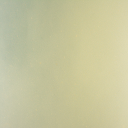
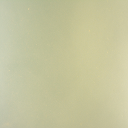
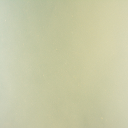
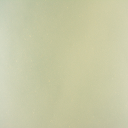
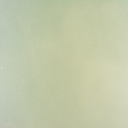
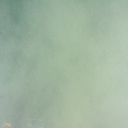
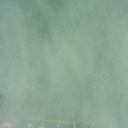
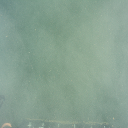
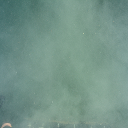
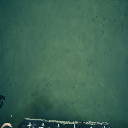
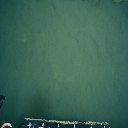
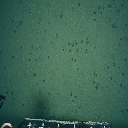

In [5]:
# see the outputs
pipeline.images

## Create a new pipeline with one more step

In [6]:
# Create a new pipeline with one more step
open_layer_params = {
    "convert": [
        {
            "mode": "bits",
            "params": {
                "output_bits": 8,
            },
        },
    ],
    "sampling": [{"mode": "percent", "params": {"value": 0.1}}],
}
pipeline_steps = [
    ("raw", OpenLayer, open_layer_params),
    ("gray", ColourLayer, {"mode": "grayscale"}),
]

In [7]:
# Instantiate the pipeline class and see the step described in the pipeline_steps variable
pipeline = Pipeline(
    config_file_path="../config_files/config_simple.yml",
    steps=pipeline_steps,
)
pipeline.steps

[('raw',
  paidiverpy.open_layer.open_layer.OpenLayer,
  {'convert': [{'mode': 'bits', 'params': {'output_bits': 8}}],
   'sampling': [{'mode': 'percent', 'params': {'value': 0.1}}],
   'name': 'raw',
   'step_name': 'raw'}),
 ('gray',
  paidiverpy.colour_layer.colour_layer.ColourLayer,
  {'mode': 'grayscale', 'name': 'gray', 'step_name': 'colour'})]

In [8]:
# See the pipeline
pipeline

In [9]:
# See the updated configuration file
pipeline.config

{
    "general": {
        "name": "raw",
        "step_name": "raw",
        "sample_data": "benthic_csv",
        "input_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/images",
        "metadata_path": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/metadata_benthic_csv.csv",
        "metadata_type": "CSV_FILE",
        "image_type": "PNG",
        "append_data_to_metadata": "/home/tobfer/.paidiverpy_cache/benthic_csv/metadata/appended_metadata_benthic_csv.csv",
        "is_remote": false,
        "output_is_remote": false,
        "output_path": "output",
        "n_jobs": 1,
        "client": null,
        "track_changes": true,
        "rename": "datetime",
        "sampling": [
            {
                "mode": "percent",
                "params": {
                    "value": 0.1
                }
            }
        ],
        "convert": [
            {
                "mode": "bits",
                "params": {
                    "output_bits": 8
             

In [10]:
# Run your pipeline
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-03-06 10:29:06 | Processing images using 1 cores


INFO:paidiverpy:Processing images using 1 cores


☁ paidiverpy ☁  |       INFO | 2025-03-06 10:29:06 | Running step 0: raw - OpenLayer


INFO:paidiverpy:Running step 0: raw - OpenLayer


Open Images:   0%|                                        | 0/5 [00:00<?, ?it/s]

...

INFO:paidiverpy:Running step 1: gray - ColourLayer


Processing images:   0%|                                  | 0/5 [00:00<?, ?it/s]

Processing images: 100%|███████████████████████| 5/5 [00:00<00:00, 11841.63it/s]

☁ paidiverpy ☁  |       INFO | 2025-03-06 10:29:07 | Step 1 completed


INFO:paidiverpy:Step 1 completed


Step: raw
Image: [[[160 180 167 255]
  [160 180 169 255]
  [162 180 169 255]
  ...
  [162 203 206 255]
  [163 205 207 255]
  [161 204 206 255]]

 [[164 181 170 255]
  [161 180 170 255]
  [162 180 169 255]
  ...
  [162 205 207 255]
  [161 204 207 255]
  [163 204 208 255]]

 [[162 180 168 255]
  [165 181 170 255]
  [164 181 172 255]
  ...
  [164 205 208 255]
  [163 204 207 255]
  [163 205 209 255]]

 ...

 [[170 192 191 255]
  [170 194 191 255]
  [170 194 194 255]
  ...
  [169 208 215 255]
  [171 210 213 255]
  [170 209 215 255]]

 [[172 193 193 255]
  [171 195 193 255]
  [170 193 193 255]
  ...
  [168 207 213 255]
  [169 209 213 255]
  [171 208 212 255]]

 [[174 195 193 255]
  [170 194 194 255]
  [170 193 193 255]
  ...
  [168 207 214 255]
  [169 207 214 255]
  [171 208 215 255]]]
Image: [[[179 203 195 255]
  [180 204 195 255]
  [179 204 195 255]
  ...
  [171 208 211 255]
  [170 209 209 255]
  [171 208 210 255]]

 [[182 204 197 255]
  [179 202 197 255]
  [180 202 195 255]
  ...
  [171 209 210 255]
  [171 208 210 255]
  [173 210 212 255]]

 [[181 204 196 255]
  [180 203 195 255]
  [181 203 198 255]
  ...
  [173 208 211 255]
  [171 208 211 255]
  [171 209 211 255]]

 ...

 [[172 195 192 255]
  [175 197 195 255]
  [173 198 198 255]
  ...
  [173 203 203 255]
  [171 202 203 255]
  [173 203 203 255]]

 [[173 195 193 255]
  [173 195 193 255]
  [174 196 197 255]
  ...
  [171 201 202 255]
  [172 202 203 255]
  [174 204 204 255]]

 [[175 196 194 255]
  [174 196 195 255]
  [172 196 196 255]
  ...
  [173 202 202 255]
  [173 202 203 255]
  [173 202 202 255]]]
Image: [[[185 207 194 255]
  [186 207 196 255]
  [186 206 195 255]
  ...
  [176 207 199 255]
  [175 207 201 255]
  [176 207 200 255]]

 [[188 207 197 255]
  [189 208 197 255]
  [189 208 197 255]
  ...
  [177 209 203 255]
  [178 208 202 255]
  [177 207 201 255]]

 [[188 207 196 255]
  [188 207 199 255]
  [190 209 202 255]
  ...
  [179 210 207 255]
  [178 207 201 255]
  [179 206 202 255]]

 ...

 [[176 191 182 255]
  [179 193 187 255]
  [176 193 188 255]
  ...
  [175 202 199 255]
  [176 202 197 255]
  [178 203 198 255]]

 [[174 189 179 255]
  [178 193 184 255]
  [175 192 188 255]
  ...
  [176 200 199 255]
  [180 201 197 255]
  [181 204 201 255]]

 [[176 191 183 255]
  [175 190 184 255]
  [176 191 184 255]
  ...
  [177 201 197 255]
  [176 201 197 255]
  [177 200 197 255]]]
Image: [[[102 106  64 255]
  [105 109  69 255]
  [104 109  69 255]
  ...
  [120 126  93 255]
  [124 129  97 255]
  [123 129  97 255]]

 [[105 107  66 255]
  [104 106  65 255]
  [107 108  68 255]
  ...
  [122 127  93 255]
  [121 126  93 255]
  [121 126  95 255]]

 [[103 106  65 255]
  [104 105  65 255]
  [104 104  65 255]
  ...
  [122 127  94 255]
  [118 122  90 255]
  [121 126  94 255]]

 ...

 [[106 107  83 255]
  [108 107  82 255]
  [139 146 153 255]
  ...
  [140 147 120 255]
  [138 145 119 255]
  [140 148 119 255]]

 [[107 110  88 255]
  [118 120 107 255]
  [143 153 162 255]
  ...
  [143 149 122 255]
  [143 150 121 255]
  [142 151 124 255]]

 [[106 106  83 255]
  [137 145 158 255]
  [138 150 160 255]
  ...
  [142 150 123 255]
  [145 150 123 255]
  [141 149 120 255]]]
Image: [[[ 63  70  23 255]
  [ 66  72  25 255]
  [ 65  70  25 255]
  ...
  [ 69  80  37 255]
  [ 77  86  40 255]
  [ 73  82  37 255]]

 [[ 63  69  26 255]
  [ 66  71  27 255]
  [ 61  67  23 255]
  ...
  [ 74  81  38 255]
  [ 75  84  40 255]
  [ 72  82  37 255]]

 [[ 67  72  28 255]
  [ 62  69  23 255]
  [ 64  70  23 255]
  ...
  [ 74  85  41 255]
  [ 72  80  36 255]
  [ 73  81  37 255]]

 ...

 [[ 42  46  12 255]
  [ 46  48   9 255]
  [ 96 103 121 255]
  ...
  [ 59  62  26 255]
  [ 57  62  20 255]
  [ 55  57  19 255]]

 [[ 46  48  16 255]
  [ 48  51  37 255]
  [124 133 150 255]
  ...
  [ 55  59  20 255]
  [ 55  56  23 255]
  [ 56  59  20 255]]

 [[ 39  39  10 255]
  [117 126 150 255]
  [125 136 160 255]
  ...
  [ 54  55  19 255]
  [ 52  55  17 255]
  [ 55  55  19 255]]]
Step: gray
Image: [[174 174 175 ... 199 201 200]
 [176 175 175 ... 201 200 201]
 [174
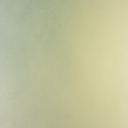
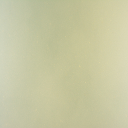
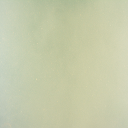
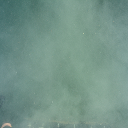
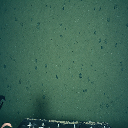
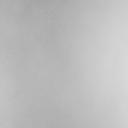
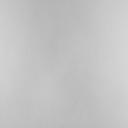
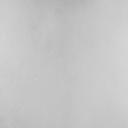
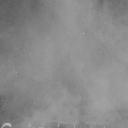
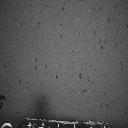

In [11]:
# See the ouput images
pipeline.images

In [12]:
pipeline.images.show(image_number=8)

## Export pipeline to configuration file

After creating the pipeline, you can export it to a configuration file and reuse it

In [13]:
pipeline.export_config("new_config.yml")

In [14]:
pipeline = Pipeline(config_file_path="new_config.yml")

In [15]:
pipeline

In [16]:
pipeline.run()

☁ paidiverpy ☁  |       INFO | 2025-03-06 10:29:07 | Processing images using 1 cores


INFO:paidiverpy:Processing images using 1 cores


☁ paidiverpy ☁  |       INFO | 2025-03-06 10:29:07 | Running step 0: raw - OpenLayer


INFO:paidiverpy:Running step 0: raw - OpenLayer


Open Images:   0%|                                        | 0/5 [00:00<?, ?it/s]

...

INFO:paidiverpy:Running step 1: gray - ColourLayer


Processing images:   0%|                                  | 0/5 [00:00<?, ?it/s]

Processing images: 100%|███████████████████████| 5/5 [00:00<00:00, 17105.64it/s]

☁ paidiverpy ☁  |       INFO | 2025-03-06 10:29:08 | Step 1 completed


INFO:paidiverpy:Step 1 completed


☁ paidiverpy ☁  |       INFO | 2025-05-28 14:35:49 | Processing images using 1 cores
☁ paidiverpy ☁  |       INFO | 2025-05-28 14:35:49 | Running step 0: raw - OpenLayer
☁ paidiverpy ☁  |       INFO | 2025-05-28 14:35:49 | Number of images to be removed: 34. Total number of images: 49


Processing images: 100%|██████████████████████████| 15/15 [00:00<00:00, 2259.54it/s]


☁ paidiverpy ☁  |       INFO | 2025-05-28 14:35:49 | Step 0 completed


INFO:paidiverpy:Step 0 completed


Column
    [0] Column
        [0] IntSlider(end=16, name='Output Bits', start=1, value=8)
        [1] FloatSlider(name='Sampling Value', start=0.01, step=0.01, value=0.3)
        [2] Checkbox(name='Apply Grayscale')
    [1] Row
        [0] Column
            [0] Markdown(str)
            [1] Str(list)
            [2] Markdown(str)
            [3] HTML(ImagesLayer)
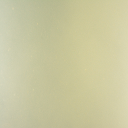
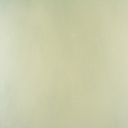
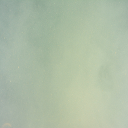
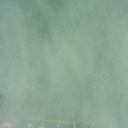
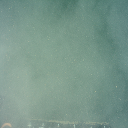
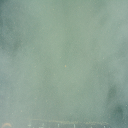
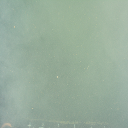
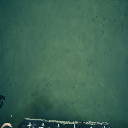
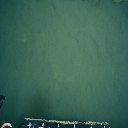
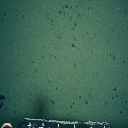
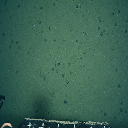
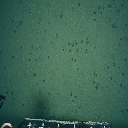

In [1]:
import panel as pn
pn.extension()

from paidiverpy.colour_layer import ColourLayer
from paidiverpy.open_layer import OpenLayer
from paidiverpy.pipeline import Pipeline

# Panel-interactive function
def create_pipeline(output_bits=8, sampling_value=0.3, grayscale=False):
    open_layer_params = {
        "convert": [
            {
                "mode": "bits",
                "params": {"output_bits": output_bits},
            }
        ],
        "sampling": [{"mode": "percent", "params": {"value": sampling_value}}],
    }

    pipeline_steps = [("raw", OpenLayer, open_layer_params)]

    if grayscale:
        pipeline_steps.append(("gray", ColourLayer, {"mode": "grayscale"}))

    pipeline = Pipeline(
        config_file_path="../config_files/config_simple.yml",
        steps=pipeline_steps,
    )

    # Run the pipeline
    pipeline.run()

    # Display the pipeline and the images
    return pn.Column(
        "### Pipeline Steps", pipeline.steps,
        "### Output Images", pipeline.images
    )

# Create the interactive UI
interactive_ui = pn.interact(
    create_pipeline,
    output_bits=pn.widgets.IntSlider(name="Output Bits", start=1, end=16, value=8),
    sampling_value=pn.widgets.FloatSlider(name="Sampling Value", start=0.01, end=1.0, step=0.01, value=0.3),
    grayscale=pn.widgets.Checkbox(name="Apply Grayscale", value=False)
)

interactive_ui